In [3]:
import sys
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from accelerate import Accelerator
import pandas as pd

# Add src/ directory to Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src")))

In [4]:
from qwen import load_qwen
from lora import LoRALinear
from processor import load_and_preprocess
from data import process_sequences

In [ ]:
# Force everything to CPU
device = torch.device("cpu")

# Load model and move to CPU
model, tokenizer = load_qwen()
model.to(device)

# Apply LoRA to Query & Value Projection Layers
lora_rank = 8
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)  
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

# Load dataset
train_texts, val_texts = load_and_preprocess("../coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8)

# Set optimized training settings
max_ctx_length = 256  #  Updated to match skeleton
batch_size = 2  #  Use correct batch size
learning_rate = 0.0002

# Convert tokenized text into tensors
train_input_ids = process_sequences(train_texts, tokenizer, max_ctx_length, stride=max_ctx_length // 2)
val_input_ids = process_sequences(val_texts, tokenizer, max_ctx_length)

#  Prepare DataLoaders
train_dataset = TensorDataset(train_input_ids)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input_ids)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

#  Optimizer (only trainable LoRA parameters)
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=learning_rate, weight_decay=0.05)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10000)

#  Use Accelerator for efficient training
accelerator = Accelerator()
model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)

train_losses = []
val_losses = []
true_series = []
predicted_series = []
eval_interval = 1000  # Evaluate validation loss every 100 steps

for param in model.parameters():
    param.data = param.data.to("cpu")
    if param.grad is not None:
        param.grad.data = param.grad.data.to("cpu")

for buffer in model.buffers():
    buffer.data = buffer.data.to("cpu")

#  Train LoRA Model
model.train()
steps = 0
while steps < 5000:
    progress_bar = tqdm(train_loader, desc=f"Steps {steps}")
    for (batch,) in progress_bar:
        optimizer.zero_grad()
        batch = batch.to(device, dtype=torch.long)  # Ensure input is on CPU

        outputs = model(batch, labels=batch)
        loss = outputs.loss
        accelerator.backward(loss)
        optimizer.step()
        steps += 1

        train_losses.append(loss.item())

        progress_bar.set_postfix(loss=loss.item())

        if steps % eval_interval == 0:
            model.eval()
            val_loss_total = 0
            with torch.no_grad():
                for (val_batch,) in val_loader:
                    val_batch = val_batch.to(device, dtype=torch.long)
                    val_outputs = model(val_batch, labels=val_batch)
                    val_loss_total += val_outputs.loss.item()
            avg_val_loss = val_loss_total / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f"Step {steps}: Validation Loss = {avg_val_loss}")
            model.train()  # Switch back to training model

        if steps >= 5000:
            break

#  Final Model Save
torch.save(model.state_dict(), "../models/lora_qwen2.5_3c_6.pth")

#  Save Train & Validation Losses to CSV
pd.DataFrame({"train_loss": train_losses}).to_csv(f"../csv/train_loss_3c_6.csv", index=False)
pd.DataFrame({"val_loss": val_losses}).to_csv(f"../csv/val_loss_3c_6.csv", index=False)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.
Steps 0:   0%|          | 0/20 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Steps 0:   0%|          | 0/20 [02:45<?, ?it/s]


KeyboardInterrupt: 

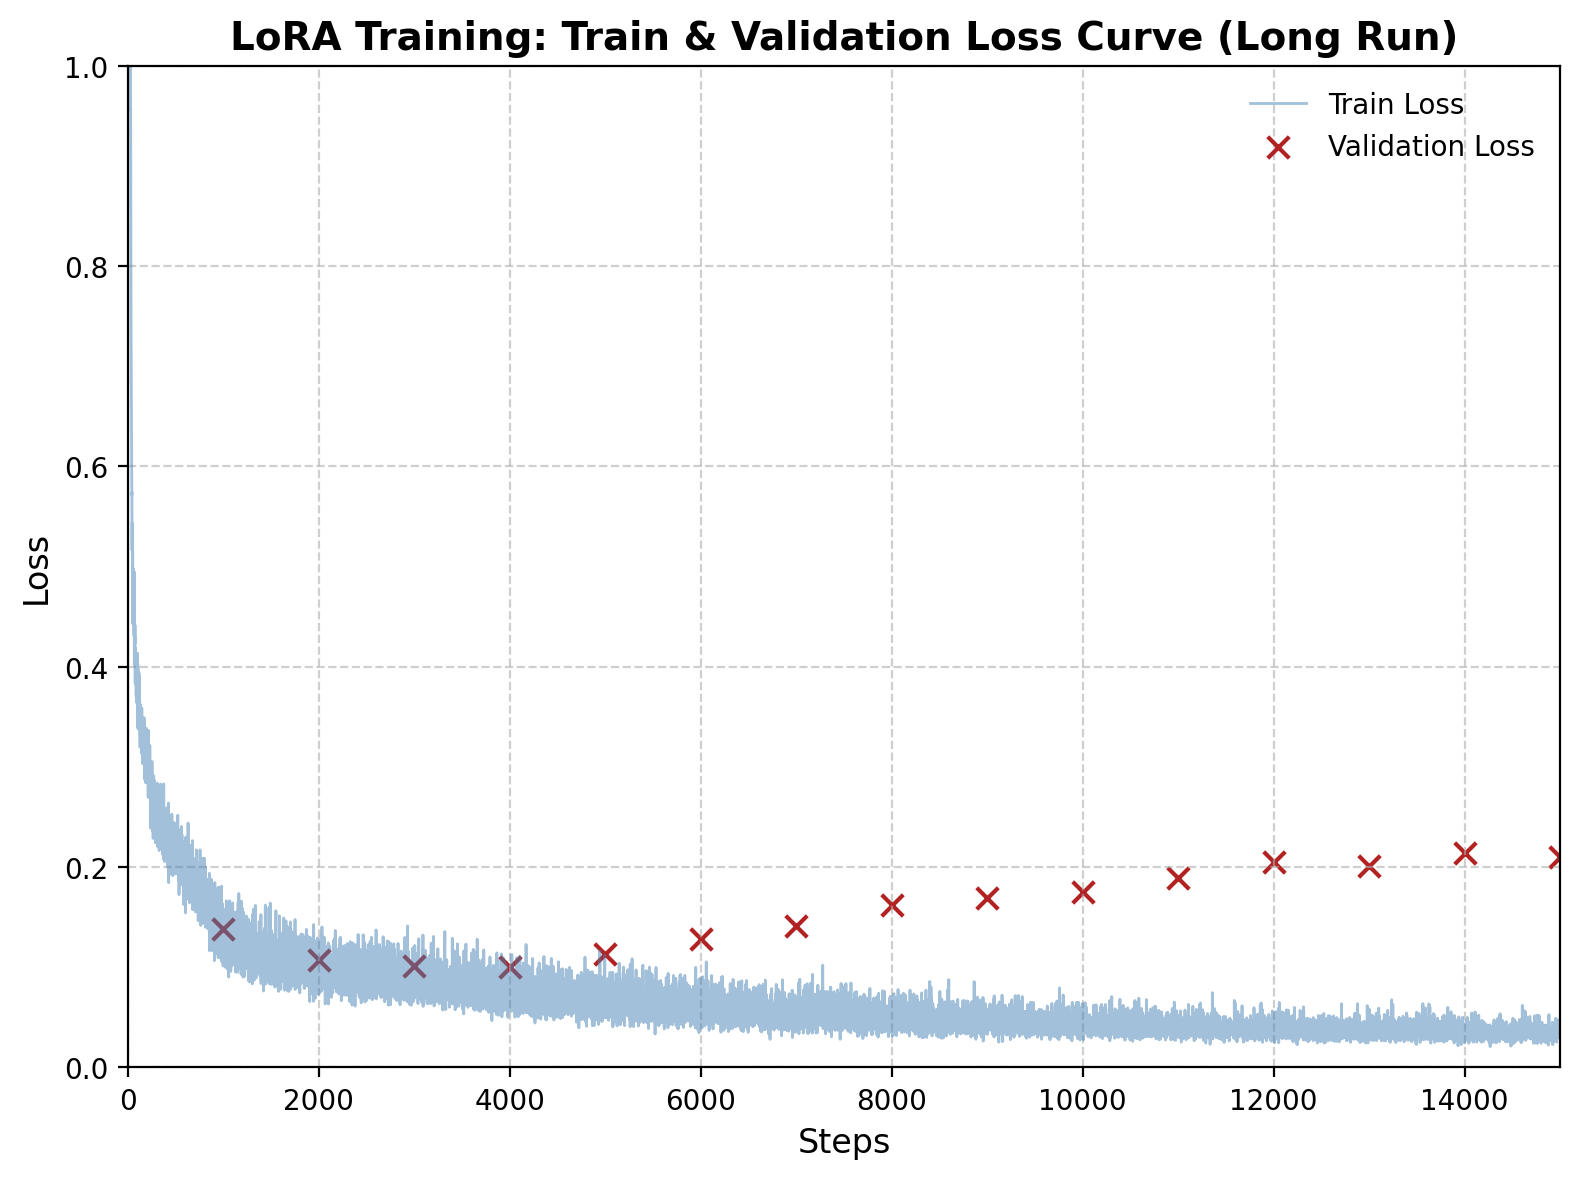

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training and validation loss data
train_loss = pd.read_csv("../csv/train_loss_3c_6.csv")["train_loss"]
val_loss = pd.read_csv("../csv/val_loss_3c_6.csv")["val_loss"]

# Generate x-axis values
train_steps = range(len(train_loss))
val_steps = [i * 1000 for i in range(1, len(val_loss)+1)]  # Validation loss is recorded every 100 steps


plt.figure(figsize=(8, 6), dpi=200)

#  Plot training loss with smoother style
plt.plot(train_steps, train_loss, label="Train Loss", color="steelblue", linewidth=1, alpha=0.5)

#  Overlay validation loss clearly
plt.scatter(val_steps, val_loss, color="firebrick", label="Validation Loss", marker="x", s=60, linewidths=1.5)


plt.ylim(0, 1)
plt.xlim(0, max(train_steps))
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("LoRA Training: Train & Validation Loss Curve (Long Run)", fontsize=14, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

